In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr
import mne

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend

Using notebook 3d backend.


# Aim 1.1

_Load HGA_

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 1853/1853 [01:21<00:00, 22.74it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 455680
PIC electrode count: 400960


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [6]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
HGAs[['x','y','z']] = HGAs[['x','y','z']].values + translation

## Helper FUNC

In [ ]:
import pyvista as pv
from mne.viz import Brain
from scipy.spatial import cKDTree
from matplotlib.patches import Patch

insula_patterns = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup'
]

insula_labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir
)

lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(pattern in lab.name for pattern in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        return pial_coords[vertices].mean(axis=0)
    return None

lh_insula_center = get_insula_center(insula_labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(insula_labels, 'rh', rh_pial_coords)

def filter_windows(df, windows):
    masks = []
    for phase, tmin, tmax in windows:
        phase_mask = df.phase == phase
        if tmin is not None:
            phase_mask &= df.time >= tmin
        if tmax is not None:
            phase_mask &= df.time <= tmax
        masks.append(phase_mask)
    if not masks:
        return df.iloc[0:0]
    combined = masks[0]
    for mask in masks[1:]:
        combined |= mask
    return df[combined]

def get_panel_c1_phase_xaxis(phase):
    xlim = PANEL_C_CONFIG['panel_c1_phase_xlims'][phase]
    xticks = PANEL_C_CONFIG['panel_c1_phase_xticks'][phase]
    return xlim, xticks

def apply_panel_c1_phase_xaxis(ax, phase):
    xlim, xticks = get_panel_c1_phase_xaxis(phase)
    ax.set_xlim(*xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], fontsize=7)

def get_sig_channels(df, windows, group_col, group_val):
    sub = filter_windows(df[df[group_col] == group_val], windows)
    return set(sub.loc[sub['mask'] == True, 'channel'].unique())

PANEL_C_CONFIG = {
    'sternberg_phase': 'maintenance',
    'repeat_phase': 'delay',
    'repeat_task': 'LexicalDelay',
    'repeat_description': 'Repeat',
    'sternberg_sig_mode': 'environment',  # 'environment' | 'any_condition'
    'panel_c1_windows': [('maintenance', None, None)],
    'panel_c1_phases': ['maintenance', 'probe'],
    'panel_c1_phase_width_ratios': [5, 3],
    'panel_c1_fig_width_cm': 6,
    'panel_c1_phase_xlims': {
        'maintenance': (0, 3),
        'probe': (0, 2),
    },
    'panel_c1_phase_xticks': {
        'maintenance': [0, 1, 2, 3],
        'probe': [0, 1, 2],
    },
    'sternberg_windows': [('maintenance', None, None)],
    'repeat_windows': [('delay', None, None)],
}

def get_sig_channels_any_load(df, windows, group_col, group_val):
    sub = df
    if isinstance(group_val, (list, tuple, set)):
        sub = sub[sub[group_col].isin(group_val)]
    else:
        sub = sub[sub[group_col] == group_val]
    sub = filter_windows(sub, windows)
    return set(sub.loc[sub['mask'] == True, 'channel'].unique())

def get_sternberg_sig_channels(df, windows, config=None):
    config = config or PANEL_C_CONFIG
    if config.get('sternberg_sig_mode') == 'any_condition':
        sub = filter_windows(df, windows)
        return set(sub.loc[sub['mask'] == True, 'channel'].unique())
    return get_sig_channels_any_load(df, windows, 'condition_group', 'environment')

def add_sternberg_content_group(df):
    out = df.copy()
    out['content_group'] = out['condition_group'].map({
        'environment': 'environment',
        'word': 'Speech',
        'nonword': 'Speech',
    })
    return out.dropna(subset=['content_group'])

def _spatial_channel_means(df, windows, channels):
    sub = filter_windows(df[df.channel.isin(channels)], windows)
    if sub.empty:
        return pd.DataFrame()
    return sub.groupby('channel').agg({
        'value': 'mean',
        'x': 'first', 'y': 'first', 'z': 'first',
        'roi': 'first', 'label': 'first', 'hemi': 'first',
        'subject': 'first', 'description': 'first', 'task': 'first', 'modality': 'first',
    })

def subset_panel_c2_common(sternberg_df, repeat_df):
    """Restrict Panel C2 to subjects present in both Sternberg and lexical repeat."""
    common = sorted(set(sternberg_df.subject) & set(repeat_df.subject))
    print(f'Panel C2 common subjects (n={len(common)}): {common}')
    sternberg_common = sternberg_df[sternberg_df.subject.isin(common)].copy()
    repeat_common = repeat_df[repeat_df.subject.isin(common)].copy()
    return sternberg_common, repeat_common, common

def plot_repeat_channel_heatmap(
    df,
    roi,
    hemi='L',
    phases=None,
    cmap=None,
    exclude_subjects=('D0121',),
    vmin=0,
    vmax=1.5,
    savepath=None,
    height_per_channel_cm=0.02,
):
    """Per-channel HGA heatmap across phases (Lexical Repeat, sound); fig2-style."""
    phases = phases or ['stimulus', 'delay', 'go', 'response']
    subset = df[
        (df.description == 'Repeat')
        & (df.modality == 'sound')
        & (df.hemi == hemi)
        & (df.roi == roi)
    ].copy()
    if exclude_subjects:
        subset = subset[~subset.subject.isin(exclude_subjects)]

    agg_data = subset.groupby(['channel', 'time', 'phase']).agg({
        'value': 'mean',
        'mask': lambda x: x.any(),
    }).reset_index()
    agg_data.loc[~agg_data['mask'], 'value'] = np.nan

    max_channels = 0
    phase_channel_map = {}
    for phase in phases:
        phase_data = agg_data[agg_data.phase == phase]
        sig_channels = phase_data.loc[phase_data['mask'] == True, 'channel'].unique()
        first_sig_times = []
        for ch in sig_channels:
            ch_data = phase_data[phase_data.channel == ch]
            sig_times = ch_data.loc[ch_data['mask'] == True, 'time'].values
            first_sig_times.append((ch, sig_times.min() if len(sig_times) else np.inf))
        sorted_channels = [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]
        phase_channel_map[phase] = sorted_channels
        max_channels = max(max_channels, len(sorted_channels))

    fig_h = max(3 * cm, float(height_per_channel_cm * max(max_channels, 1) * cm))
    fig, axes = plt.subplots(
        nrows=1, ncols=len(phases),
        figsize=(2.5 * len(phases) * cm, fig_h),
    )
    if len(phases) == 1:
        axes = [axes]

    for ax, phase in zip(axes, phases):
        sorted_channels = phase_channel_map[phase]
        phase_data = agg_data[agg_data.phase == phase]

        if len(sorted_channels) == 0:
            ax.text(
                0.5, 0.5, 'No significant\nchannels',
                ha='center', va='center', transform=ax.transAxes, fontsize=7,
            )
            ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylim(0, max(max_channels, 1))
            continue

        phase_data_filtered = phase_data[phase_data.channel.isin(sorted_channels)]
        pivot_data = phase_data_filtered.pivot(index='channel', columns='time', values='value')
        pivot_data = pivot_data.reindex(index=sorted_channels)

        da = xr.DataArray(
            pivot_data.values,
            coords={'channel': pivot_data.index, 'time': pivot_data.columns},
            dims=['channel', 'time'],
        )

        time_values = da.coords['time'].values.astype(float)
        step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
        time_edges = np.concatenate((
            [time_values[0] - step / 2],
            time_values[:-1] + step / 2,
            [time_values[-1] + step / 2],
        ))
        channel_edges = np.arange(len(sorted_channels) + 1)
        T, C = np.meshgrid(time_edges, channel_edges)

        ax.pcolormesh(
            T, C, da.values, cmap=cmap, vmin=vmin, vmax=vmax,
            shading='auto', rasterized=True,
        )
        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines['left'].set_visible(False)
        ax.set_xticks([-1, 0, 1, 2])
        ax.set_xticklabels(['-1', '0', '1', '2'], fontsize=7)
        ax.set_yticks([])
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, max(max_channels, 1))
        if ax == axes[0]:
            ax.set_ylabel(
                f'{roi} {hemi}H Channels (n={len(sorted_channels)})', fontsize=7,
            )

    plt.suptitle(f'{roi} {hemi}', fontsize=8)
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    return fig, axes


def plot_sternberg_condition_channel_heatmap(
    df,
    roi='AIC',
    conditions=None,
    condition_labels=None,
    phases=None,
    phase_width_ratios=None,
    sig_windows=None,
    condition_cmaps=None,
    condition_colors=None,
    vmin=0,
    vmax=1.5,
    height_per_channel_cm=0.035,
    savepath=None,
):
    """Per-channel Sternberg heatmap: phases as columns, conditions stacked on y-axis.

    Cross-load rule: value=mean across loads; mask=any load significant.
    """
    conditions = conditions or ['environment', 'word', 'nonword']
    condition_labels = condition_labels or ['Environmental Sound', 'Word', 'Non-word']
    phases = phases or PANEL_C_CONFIG.get('panel_c1_phases', ['maintenance', 'probe'])
    phase_width_ratios = phase_width_ratios or PANEL_C_CONFIG.get(
        'panel_c1_phase_width_ratios', [5, 3],
    )
    fig_width_cm = PANEL_C_CONFIG.get('panel_c1_fig_width_cm', sum(phase_width_ratios) * 0.375)
    if sig_windows is None:
        sig_windows = PANEL_C_CONFIG.get('panel_c1_windows')
    condition_cmaps = condition_cmaps or {
        'environment': reds,
        'word': blues,
        'nonword': greens,
    }
    condition_colors = condition_colors or {
        'environment': red,
        'word': blue,
        'nonword': green,
    }

    subset = df[(df.modality == 'sound') & (df.roi == roi)].copy()

    agg_parts = []
    for cond in conditions:
        cond_sub = subset[subset['condition_group'] == cond]
        if cond_sub.empty:
            continue
        agg = cond_sub.groupby(['channel', 'time', 'phase']).agg({
            'value': 'mean',
            'mask': lambda x: x.any(),
        }).reset_index()
        agg['condition_group'] = cond
        agg.loc[~agg['mask'], 'value'] = np.nan
        agg_parts.append(agg)
    if not agg_parts:
        raise ValueError(f'No Sternberg data for roi={roi}')
    agg_data = pd.concat(agg_parts, ignore_index=True)

    sorted_row_ids = []
    condition_boundaries = [0]
    condition_counts = {}

    for cond, label in zip(conditions, condition_labels):
        cond_agg = agg_data[agg_data['condition_group'] == cond]
        if cond_agg.empty:
            condition_counts[label] = 0
            condition_boundaries.append(len(sorted_row_ids))
            continue

        if sig_windows:
            win_data = filter_windows(cond_agg, sig_windows)
            sig_channels = win_data.loc[win_data['mask'] == True, 'channel'].unique()
        else:
            sig_channels = cond_agg.loc[cond_agg['mask'] == True, 'channel'].unique()

        sig_rows = cond_agg[cond_agg['channel'].isin(sig_channels) & cond_agg['mask']]
        earliest_time = sig_rows.groupby('channel')['time'].min().to_dict()
        cond_sorted = sorted(sig_channels, key=lambda ch: earliest_time.get(ch, np.inf))

        condition_counts[label] = len(cond_sorted)
        for ch in cond_sorted:
            sorted_row_ids.append(f'{cond}::{ch}')
        condition_boundaries.append(len(sorted_row_ids))

    max_channels = len(sorted_row_ids)
    agg_data['row_id'] = agg_data['condition_group'] + '::' + agg_data['channel']

    fig_h = float(height_per_channel_cm * max(max_channels, 1) * cm)
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(phases),
        figsize=(fig_width_cm * cm, fig_h),
        gridspec_kw={'width_ratios': phase_width_ratios},
    )
    if len(phases) == 1:
        axes = [axes]

    for ax, phase in zip(axes, phases):
        if max_channels == 0:
            ax.text(
                0.5, 0.5, 'No significant\nchannels',
                ha='center', va='center', transform=ax.transAxes, fontsize=7,
            )
            ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylim(0, max(max_channels, 1))
            continue

        phase_data = agg_data[agg_data['phase'] == phase]
        phase_data = phase_data[phase_data['row_id'].isin(sorted_row_ids)]
        pivot_data = phase_data.pivot(index='row_id', columns='time', values='value')
        pivot_data = pivot_data.reindex(index=sorted_row_ids)

        xlim, xticks = get_panel_c1_phase_xaxis(phase)
        time_cols = pivot_data.columns.astype(float)
        keep = (time_cols >= xlim[0]) & (time_cols <= xlim[1])
        pivot_data = pivot_data.loc[:, keep]

        da = xr.DataArray(
            pivot_data.values,
            coords={'row_id': pivot_data.index, 'time': pivot_data.columns},
            dims=['row_id', 'time'],
        )

        time_values = da.coords['time'].values.astype(float)
        step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
        time_edges = np.concatenate((
            [time_values[0] - step / 2],
            time_values[:-1] + step / 2,
            [time_values[-1] + step / 2],
        ))

        for i, cond in enumerate(conditions):
            start = condition_boundaries[i]
            end = condition_boundaries[i + 1]
            if start == end:
                continue
            block_values = da.values[start:end, :]
            channel_edges = np.arange(start, end + 1)
            T, C = np.meshgrid(time_edges, channel_edges)
            ax.pcolormesh(
                T, C, block_values,
                cmap=condition_cmaps.get(cond, reds),
                vmin=vmin, vmax=vmax,
                shading='auto', rasterized=True,
            )

        for boundary in condition_boundaries[1:-1]:
            ax.axhline(y=boundary, color='k', linestyle='--', linewidth=0.5, alpha=0.8, zorder=10)

        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines['left'].set_visible(False)
        apply_panel_c1_phase_xaxis(ax, phase)
        ax.set_yticks([])
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, max(max_channels, 1))

        if ax == axes[0]:
            ax.set_ylabel(f'{roi} Channels', fontsize=7)
            for i, (cond, label) in enumerate(zip(conditions, condition_labels)):
                y_pos = (condition_boundaries[i] + condition_boundaries[i + 1]) / 2
                if condition_counts.get(label, 0) > 0:
                    ax.text(
                        -0.12, y_pos / max(max_channels, 1), f'{label}\n(n={condition_counts[label]})',
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=6, color=condition_colors.get(cond, 'black'), alpha=0.9,
                    )
        else:
            ax.set_ylabel('', fontsize=7)

    plt.suptitle(f'{roi} Sternberg by condition', fontsize=8)
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    return fig, axes


def load_decision_vs_repeat_contrast(tasks=('LexicalDelay',), ref='bipolar'):
    """Load DecisionVsRepeat univariate contrast results and attach channel metadata."""
    contrast_paths = []
    for task in tasks:
        contrast_paths.extend(
            BIDSPath(
                root=f'../results/{task}({ref})',
                datatype='univariate',
                description='DecisionVsRepeat',
                suffix='highgamma',
                check=False,
            ).match()
        )
    print(f"Found {len(contrast_paths)} DecisionVsRepeat contrast files")
    if not contrast_paths:
        return pd.DataFrame()

    contrast_dfs = []
    for path in tqdm(contrast_paths):
        df = pd.read_csv(path)
        df['subject'] = path.subject
        df['task'] = path.task
        contrast_dfs.append(df)
    dec_vs_rep = pd.concat(contrast_dfs, ignore_index=True)

    channel_meta = HGAs[[
        'channel', 'roi', 'hemi', 'label', 'x', 'y', 'z'
    ]].drop_duplicates(subset='channel')
    dec_vs_rep = dec_vs_rep.merge(channel_meta, on='channel', how='left')

    if 'exclude_chn' in globals():
        dec_vs_rep = dec_vs_rep[~dec_vs_rep.channel.isin(exclude_chn)]
    dec_vs_rep = dec_vs_rep[dec_vs_rep.channel.isin(HGAs.channel.unique())]
    print(
        f"DecisionVsRepeat rows={len(dec_vs_rep)}, "
        f"subjects={dec_vs_rep.subject.nunique()}, "
        f"channels={dec_vs_rep.channel.nunique()}"
    )
    return dec_vs_rep

def get_decision_gt_repeat_channels(
    dec_vs_rep, phase='delay', t_window=(0, 0.8), roi='AIC'
):
    """Return significant channels where Decision > Repeat in the requested window."""
    if dec_vs_rep.empty:
        print('DecisionVsRepeat contrast table is empty.')
        return pd.DataFrame()

    tmin, tmax = t_window
    sub = dec_vs_rep[
        (dec_vs_rep.significant == True)
        & (dec_vs_rep['mask'] == True)
        & (dec_vs_rep.phase == phase)
        & (dec_vs_rep.time > tmin)
        & (dec_vs_rep.time < tmax)
        & (dec_vs_rep.direction == 'Decision')
    ].copy()
    if roi is not None:
        sub = sub[sub.roi == roi]

    if sub.empty:
        print(
            f'No significant Decision > Repeat channels for '
            f'phase={phase}, window={t_window}, roi={roi}.'
        )
        return pd.DataFrame()

    agg = sub.groupby('channel').agg({
        'mean_diff': 'mean',
        'x': 'first', 'y': 'first', 'z': 'first',
        'roi': 'first', 'label': 'first', 'phase': 'first', 'hemi': 'first',
        'subject': 'first', 'task': 'first', 'direction': 'first',
    }).reset_index()
    agg = agg.dropna(subset=['x', 'y', 'z'])
    print(
        f"Decision > Repeat spatial channels: n={agg.channel.nunique()}, "
        f"subjects={agg.subject.nunique()}, roi={roi}, phase={phase}, window={t_window}"
    )
    return agg

def build_spatial_overlap_cross(df_a, df_b, windows_a, windows_b, category_map):
    channels = set(category_map)
    ga = _spatial_channel_means(df_a, windows_a, channels)
    gb = _spatial_channel_means(df_b, windows_b, channels)
    records = []
    for ch, cat in category_map.items():
        parts = []
        for g in (ga, gb):
            if not g.empty and ch in g.index:
                parts.append(g.loc[ch])
        if not parts:
            continue
        row = parts[0].copy()
        row['HGA'] = float(np.mean([p['value'] for p in parts]))
        row['category'] = cat
        records.append({'channel': ch, **row.to_dict()})
    if not records:
        return pd.DataFrame()
    spatial = pd.DataFrame(records)
    return spatial.dropna(subset=['category'])


def common_subjects_across_tasks(df, tasks, **filters):
    """Subjects with data in every task after applying optional column filters."""
    subject_sets = []
    for task in tasks:
        sub = df[df.task == task]
        for col, val in filters.items():
            if isinstance(val, (list, tuple, set)):
                sub = sub[sub[col].isin(val)]
            else:
                sub = sub[sub[col] == val]
        subject_sets.append(set(sub.subject.unique()))
    if not subject_sets:
        return set()
    common = subject_sets[0]
    for other in subject_sets[1:]:
        common &= other
    return common

def classify_channel_overlap(ch_a, ch_b, label_a, label_b):
    categories = {}
    for ch in ch_a | ch_b:
        if ch in ch_a and ch in ch_b:
            categories[ch] = 'Overlap'
        elif ch in ch_a:
            categories[ch] = f'{label_a}-only'
        elif ch in ch_b:
            categories[ch] = f'{label_b}-only'
    return categories

def build_spatial_overlap(df, windows, category_map):
    channels = set(category_map)
    spatial = filter_windows(df[df.channel.isin(channels)], windows).groupby('channel').agg({
        'value': 'mean',
        'x': 'first',
        'y': 'first',
        'z': 'first',
        'roi': 'first',
        'label': 'first',
        'hemi': 'first',
        'subject': 'first',
        'description': 'first',
        'task': 'first',
        'modality': 'first',
    }).reset_index()
    spatial.rename(columns={'value': 'HGA'}, inplace=True)
    spatial['category'] = spatial.channel.map(category_map)
    return spatial.dropna(subset=['category'])

# Narrow size range so HGA magnitude is subtle; gamma < 1 boosts weaker channels.
SPATIAL_SIZE_MIN = 15
SPATIAL_SIZE_MAX = 19
SPATIAL_SIZE_GAMMA = 0.35

def hga_to_size(hga, vmin, vmax, size_min=SPATIAL_SIZE_MIN, size_max=SPATIAL_SIZE_MAX, size_gamma=SPATIAL_SIZE_GAMMA):
    if not np.isfinite(vmax - vmin) or vmax <= vmin:
        return (size_min + size_max) / 2
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    if size_gamma is not None:
        normalized = normalized ** size_gamma
    return size_min + normalized * (size_max - size_min)

def add_spatial_category_points(
    brain, coords, hga_vals, categories, tree, pial_coords, color_map, category_order,
    size_min=SPATIAL_SIZE_MIN, size_max=SPATIAL_SIZE_MAX, size_gamma=SPATIAL_SIZE_GAMMA,
):
    if coords.size == 0:
        return
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    hga_vals = np.asarray(hga_vals)
    if len(hga_vals):
        vmin = np.nanpercentile(hga_vals, 10)
        vmax = np.nanpercentile(hga_vals, 90)
    else:
        vmin, vmax = 0, 1
    for category in category_order:
        idx = np.where(categories == category)[0]
        for i in idx:
            cloud = pv.PolyData(coords_proj[i:i+1])
            brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=hga_to_size(
                    hga_vals[i], vmin, vmax,
                    size_min=size_min, size_max=size_max, size_gamma=size_gamma,
                ),
                color=color_map[category],
                lighting=False,
            )

def plot_aic_spatial_categories(
    spatial, color_map, category_order, title, save_path,
    size_min=SPATIAL_SIZE_MIN, size_max=SPATIAL_SIZE_MAX, size_gamma=SPATIAL_SIZE_GAMMA,
):
    spatial = spatial[spatial.roi == 'AIC'].copy()
    print(spatial.groupby('category')['channel'].nunique().reindex(category_order, fill_value=0))
    if spatial.empty:
        print('No AIC channels to plot.')
        return

    lh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='lh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
    )
    rh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='rh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
    )

    for lab in insula_labels:
        if any(pattern in lab.name for pattern in insula_patterns):
            if lab.hemi == 'lh':
                lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
            elif lab.hemi == 'rh':
                rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

    coords = spatial[['x', 'y', 'z']].values
    hga_vals = spatial['HGA'].values
    categories = spatial['category'].values
    mask_lh = coords[:, 0] < 0
    mask_rh = coords[:, 0] > 0

    if mask_lh.any():
        add_spatial_category_points(
            lh_brain, coords[mask_lh], hga_vals[mask_lh], categories[mask_lh],
            lh_tree, lh_pial_coords, color_map, category_order,
            size_min=size_min, size_max=size_max, size_gamma=size_gamma,
        )
    if mask_rh.any():
        add_spatial_category_points(
            rh_brain, coords[mask_rh], hga_vals[mask_rh], categories[mask_rh],
            rh_tree, rh_pial_coords, color_map, category_order,
            size_min=size_min, size_max=size_max, size_gamma=size_gamma,
        )

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

    fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
    axes[0].imshow(lh_brain.screenshot(mode='rgb'))
    axes[0].axis('off')
    axes[0].set_title('Left Insula', fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode='rgb'))
    axes[1].axis('off')
    axes[1].set_title('Right Insula', fontsize=fontsize)

    legend_elements = [Patch(facecolor=color_map[cat], label=cat) for cat in category_order]
    axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)
    plt.suptitle(f'{title} (n={spatial.channel.nunique()})', fontsize=fontsize)

    lh_brain.close()
    rh_brain.close()
    plt.subplots_adjust(bottom=0.15)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_insula_decision_effect_spatial(
    spatial_df, save_path, roi='AIC', title='Decision > Repeat',
    value_col='mean_diff', cmap=None, size_min=8, size_max=30,
):
    """Plot Decision > Repeat electrodes on insula (fig2-style: opaque, HGA-like scaling)."""
    import matplotlib.colors as mcolors

    cmap = cmap or reds
    spatial = spatial_df.copy()
    if roi is not None and 'roi' in spatial.columns:
        spatial = spatial[spatial.roi == roi].copy()
    print(f'{title}: plotting {spatial.channel.nunique() if not spatial.empty else 0} {roi} channels')

    vals = spatial[value_col].values if not spatial.empty else np.array([])
    vmin = 0
    vmax = np.nanpercentile(vals, 95) if len(vals) else 1
    vmax = max(vmax, 1e-6)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def val_to_size(v):
        normalized = np.clip((v - vmin) / (vmax - vmin), 0, 1)
        return size_min + normalized * (size_max - size_min)

    def add_effect_points(brain, coords, values, tree, pial_coords):
        if coords.size == 0:
            return
        _, indices = tree.query(coords)
        projected = pial_coords[indices]
        for pt, v in zip(projected, values):
            cloud = pv.PolyData(pt.reshape(1, 3))
            brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=float(val_to_size(v)),
                color=cmap(norm(v))[:3],
                lighting=False,
            )

    lh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='lh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
    )
    rh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='rh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
    )

    for lab in insula_labels:
        if any(pattern in lab.name for pattern in insula_patterns):
            if lab.hemi == 'lh':
                lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
            elif lab.hemi == 'rh':
                rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

    if spatial.empty:
        print('No channels to plot; saving insula surface without points.')
    else:
        coords = spatial[['x', 'y', 'z']].values
        vals = spatial[value_col].values
        mask_lh = coords[:, 0] < 0
        mask_rh = coords[:, 0] > 0
        add_effect_points(lh_brain, coords[mask_lh], vals[mask_lh], lh_tree, lh_pial_coords)
        add_effect_points(rh_brain, coords[mask_rh], vals[mask_rh], rh_tree, rh_pial_coords)

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

    fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    axes[0].imshow(lh_brain.screenshot(mode='rgb'))
    axes[0].axis('off')
    axes[0].set_title('Left Insula', fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode='rgb'))
    axes[1].axis('off')
    axes[1].set_title('Right Insula', fontsize=fontsize)

    legend_elements = [Patch(facecolor=red, label='AIC (Anterior)')]
    axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize - 1, framealpha=0.9)
    plt.suptitle(
        f'{title} ({roi}, n={spatial.channel.nunique() if not spatial.empty else 0})',
        fontsize=fontsize,
    )

    lh_brain.close()
    rh_brain.close()
    plt.subplots_adjust(bottom=0.15)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

RT_PANEL_CONFIG = {
    'ref': 'bipolar',
    'description': 'Decision',
    'delay_task': 'LexicalDelay',
    'nodelay_task': 'LexicalNoDelay',
    'delay_phase': 'Delay',
    'nodelay_phases': ('Stimulus', 'Response'),
}

def load_rt_results(task, ref='bipolar'):
    result_path = BIDSPath(
        datatype='RT',
        root=f'../results/{task}({ref})',
        suffix='highgamma',
        check=False,
    )
    full_path = result_path.match()
    if not full_path:
        print(f'No RT results found for {task}.')
        return pd.DataFrame()

    parts = []
    for path in tqdm(full_path, desc=f'RT {task}'):
        with h5py.File(path, 'r') as mat:
            score_col = 'score' if 'score' in mat else 'r2'
            score = mat[score_col][()]
            time = mat['time'][()]
            channels = [ch.decode('utf-8') for ch in mat['channels'][:]]
            mask = mat['mask'][()]

        df_score = pd.DataFrame(score, index=channels, columns=time).reset_index()
        df_score = df_score.rename(columns={'index': 'channel'})
        df_mask = pd.DataFrame(mask, index=channels, columns=time).reset_index()
        df_mask = df_mask.rename(columns={'index': 'channel'})

        df_score = df_score.melt(id_vars='channel', var_name='time', value_name=score_col)
        df_mask = df_mask.melt(id_vars='channel', var_name='time', value_name='mask')
        df = df_score.merge(df_mask, on=['channel', 'time'], how='left')

        df['subject'] = path.subject
        df['phase'] = path.processing
        df['description'] = path.description
        df['task'] = task
        parts.append(df)

    rt_df = pd.concat(parts, ignore_index=True)
    rt_df['time'] = pd.to_numeric(rt_df['time'], errors='coerce')
    rt_df['mask'] = rt_df['mask'].fillna(False).astype(bool)
    print(
        f"RT {task}: rows={len(rt_df):,}, subjects={rt_df.subject.nunique()}, "
        f"phases={sorted(rt_df.phase.unique())}"
    )
    return rt_df

def get_sig_rt_channel_scores(rt_df, phase, description='Decision', time_window=None):
    """Significant if mask==True at any time point in this phase (no default time window)."""
    if rt_df.empty:
        return set(), pd.Series(dtype=float)

    score_col = 'score' if 'score' in rt_df.columns else 'r2'
    sub = rt_df[(rt_df.description == description) & (rt_df.phase == phase)].copy()
    if time_window is not None:
        tmin, tmax = time_window
        if tmin is not None:
            sub = sub[sub.time >= tmin]
        if tmax is not None:
            sub = sub[sub.time <= tmax]
    sub = sub[sub['mask']]
    if sub.empty:
        return set(), pd.Series(dtype=float)

    scores = sub.groupby('channel')[score_col].max()
    return set(scores.index), scores

def get_nodelay_sig_rt_channels(rt_df, cfg=RT_PANEL_CONFIG):
    ch_stim, scores_stim = get_sig_rt_channel_scores(
        rt_df, 'Stimulus', cfg['description'],
    )
    ch_resp, scores_resp = get_sig_rt_channel_scores(
        rt_df, 'Response', cfg['description'],
    )
    channels = ch_stim | ch_resp
    if scores_stim.empty and scores_resp.empty:
        scores = pd.Series(dtype=float)
    elif scores_stim.empty:
        scores = scores_resp
    elif scores_resp.empty:
        scores = scores_stim
    else:
        scores = pd.concat([scores_stim, scores_resp]).groupby(level=0).max()
    print(
        f"NoDelay RT sig channels: Stimulus={len(ch_stim)}, "
        f"Response={len(ch_resp)}, union={len(channels)}"
    )
    return channels, scores, ch_stim, ch_resp

def build_rt_spatial_overlap(scores_a, scores_b, category_map, coords_df):
    records = []
    for ch, cat in category_map.items():
        coord_rows = coords_df[coords_df.channel == ch]
        if coord_rows.empty:
            continue
        score_parts = []
        if ch in scores_a.index:
            score_parts.append(float(scores_a[ch]))
        if ch in scores_b.index:
            score_parts.append(float(scores_b[ch]))
        if not score_parts:
            continue
        row = coord_rows.iloc[0].copy()
        row['HGA'] = float(np.mean(score_parts))
        row['category'] = cat
        records.append(row)
    return pd.DataFrame(records).dropna(subset=['category']) if records else pd.DataFrame()

def prepare_rt_with_roi(rt_df, coords_df, description='Decision'):
    if rt_df.empty:
        return pd.DataFrame()
    channel_meta = coords_df[['channel', 'roi']].drop_duplicates('channel')
    rt = rt_df.merge(channel_meta, on='channel', how='left')
    if 'exclude_chn' in globals():
        rt = rt[~rt.channel.isin(exclude_chn)]
    rt = rt[rt.description == description]
    return rt

def plot_rt_temporal_by_phase(
    rt_subset,
    rois=('AIC',),
    phases=None,
    palette=None,
    sig_threshold=0.1,
    ymax=0.2,
    title='Predict RT',
    save_path=None,
):
    if rt_subset.empty:
        print('No RT data to plot.')
        return

    score_col = 'score' if 'score' in rt_subset.columns else 'r2'
    phases = phases or ['Stimulus', 'Delay', 'Go', 'Response']
    palette = palette or [red]
    palette_map = dict(zip(rois, palette))

    sig = rt_subset[rt_subset['mask'] == True]
    sig_channels = sig.groupby('channel').size()
    sig_channels = sig_channels[sig_channels > 0].index.tolist()
    subset = rt_subset[rt_subset.channel.isin(sig_channels)].copy()

    pad, bar_h = 0.01, 0.01
    fig, axes = plt.subplots(
        nrows=1, ncols=len(phases), figsize=(3 * len(phases) * cm, 4 * cm),
    )

    for ax, phase in zip(axes, phases):
        legend = ax is axes[0]
        phase_data = subset[(subset.phase == phase) & (subset.roi.isin(rois))]
        g = phase_data.groupby('channel')[score_col]
        picks = (g.min().ge(-1) & g.max().le(1) & g.max().gt(0))
        picks = picks[picks].index

        sns.lineplot(
            data=phase_data[phase_data.channel.isin(picks)],
            x='time',
            y=score_col,
            ax=ax,
            legend=legend,
            hue='roi',
            hue_order=list(rois),
            palette=palette,
            lw=0.5,
            errorbar='se',
        )

        ax.set_ylabel('R²' if ax is axes[0] else '', fontsize=fontsize)
        ax.set_xlabel(f'{phase} onset (s)', fontsize=fontsize)

        ymin = 0
        bar_base = ymax + pad
        gap = bar_h * 0.1
        for i, roi in enumerate(rois):
            sig_ratio = phase_data[phase_data.roi == roi].sort_values('time')
            sig_ratio = sig_ratio.groupby('time')['mask'].mean()
            aggregated_mask = sig_ratio >= sig_threshold
            if aggregated_mask.any():
                y0 = bar_base + i * (bar_h + gap)
                ax.fill_between(
                    sig_ratio.index.values,
                    y0,
                    y0 + bar_h,
                    where=aggregated_mask.values,
                    color=palette_map[roi],
                    alpha=0.9,
                    step='mid',
                    linewidth=0,
                )
        ax.set_ylim(ymin, bar_base + len(rois) * (bar_h + gap) + bar_h)

    for ax in fig.axes:
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=1, trim=True)
        if ax.get_legend() is not None:
            ax.legend(title='', fontsize=fontsize)
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)

    plt.suptitle(title, fontsize=fontsize)
    plt.subplots_adjust(wspace=0)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_rt_temporal_task_comparison(
    task_subsets,
    rois=('AIC',),
    phases=('Stimulus', 'Response'),
    palette=None,
    sig_threshold=0.1,
    ymax=0.2,
    title='RT prediction: Decision (LexicalDelay vs LexicalNoDelay)',
    save_path=None,
):
    """Overlay multiple tasks on Stimulus/Response panels (hue = task_label)."""
    task_subsets = [(label, df) for label, df in task_subsets if df is not None and not df.empty]
    if not task_subsets:
        print('No RT data to plot.')
        return

    score_col = 'score' if 'score' in task_subsets[0][1].columns else 'r2'
    task_labels = [label for label, _ in task_subsets]
    palette = palette or [red, blue][:len(task_labels)]
    palette_map = dict(zip(task_labels, palette))

    parts = []
    for label, rt_df in task_subsets:
        sub = rt_df.copy()
        sub['task_label'] = label
        parts.append(sub)
    combined = pd.concat(parts, ignore_index=True)

    sig = combined[combined['mask'] == True]
    sig_channels = sig.groupby('channel').size()
    sig_channels = sig_channels[sig_channels > 0].index.tolist()
    subset = combined[combined.channel.isin(sig_channels)].copy()

    pad, bar_h = 0.01, 0.01
    fig, axes = plt.subplots(
        nrows=1, ncols=len(phases), figsize=(3 * len(phases) * cm, 4 * cm),
    )
    if len(phases) == 1:
        axes = [axes]

    for ax, phase in zip(axes, phases):
        legend = ax is axes[0]
        phase_data = subset[(subset.phase == phase) & (subset.roi.isin(rois))]

        plot_parts = []
        for task_label in task_labels:
            task_phase = phase_data[phase_data.task_label == task_label]
            g = task_phase.groupby('channel')[score_col]
            picks = (g.min().ge(-1) & g.max().le(1) & g.max().gt(0))
            picks = picks[picks].index
            plot_parts.append(task_phase[task_phase.channel.isin(picks)])
        if plot_parts:
            plot_df = pd.concat(plot_parts, ignore_index=True)
            sns.lineplot(
                data=plot_df,
                x='time',
                y=score_col,
                ax=ax,
                legend=legend,
                hue='task_label',
                hue_order=task_labels,
                palette=palette_map,
                lw=0.5,
                errorbar='se',
            )

        ax.set_ylabel('R²' if ax is axes[0] else '', fontsize=fontsize)
        ax.set_xlabel(f'{phase} onset (s)', fontsize=fontsize)

        ymin = 0
        bar_base = ymax + pad
        gap = bar_h * 0.1
        for i, task_label in enumerate(task_labels):
            task_phase = phase_data[phase_data.task_label == task_label].sort_values('time')
            sig_ratio = task_phase.groupby('time')['mask'].mean()
            aggregated_mask = sig_ratio >= sig_threshold
            if aggregated_mask.any():
                y0 = bar_base + i * (bar_h + gap)
                ax.fill_between(
                    sig_ratio.index.values,
                    y0,
                    y0 + bar_h,
                    where=aggregated_mask.values,
                    color=palette_map[task_label],
                    alpha=0.9,
                    step='mid',
                    linewidth=0,
                )
        ax.set_ylim(ymin, bar_base + len(task_labels) * (bar_h + gap) + bar_h)

    for ax in fig.axes:
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=1, trim=True)
        if ax.get_legend() is not None:
            ax.legend(title='', fontsize=fontsize)
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)

    plt.suptitle(title, fontsize=fontsize)
    plt.subplots_adjust(wspace=0)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def _sort_rt_channels_by_first_sig(subset, phase, channels, score_col='r2'):
    phase_data = subset[(subset.phase == phase) & (subset.channel.isin(channels))]
    first_sig_times = []
    for ch in channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data.loc[ch_data['mask'] == True, 'time'].values
        first_sig_times.append((ch, sig_times.min() if len(sig_times) else np.inf))
    return [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]


def _get_rt_task_channel_pool(task_label, rt_df, cfg=RT_PANEL_CONFIG):
    if task_label == 'Delay':
        channels, _ = get_sig_rt_channel_scores(
            rt_df, cfg['delay_phase'], cfg['description'],
        )
    else:
        channels, _, _, _ = get_nodelay_sig_rt_channels(rt_df, cfg)
    return set(channels)


def plot_rt_task_heatmap_comparison(
    task_subsets,
    rois=('AIC',),
    phases=('Stimulus', 'Response'),
    task_cmaps=None,
    channel_pools=None,
    cfg=RT_PANEL_CONFIG,
    vmin=0,
    vmax=0.4,
    height_per_channel_cm=0.015,
    title='RT prediction: Decision (AIC)',
    save_path=None,
):
    """Per-channel RT R² heatmap: tasks as rows, phases as columns."""
    task_subsets = [(label, df) for label, df in task_subsets if df is not None and not df.empty]
    if not task_subsets:
        print('No RT data to plot.')
        return

    score_col = 'score' if 'score' in task_subsets[0][1].columns else 'r2'
    task_labels = [label for label, _ in task_subsets]
    default_cmaps = {'Delay': reds, 'No-delay': blues}
    task_cmaps = task_cmaps or {label: default_cmaps.get(label, reds) for label in task_labels}
    channel_pools = channel_pools or {}

    row_max_channels = []
    for task_label, rt_df in task_subsets:
        pool = channel_pools.get(task_label)
        if pool is None:
            pool = _get_rt_task_channel_pool(task_label, rt_df, cfg)
        aic_channels = rt_df.loc[rt_df.roi.isin(rois), 'channel'].unique()
        row_max_channels.append(len(set(pool) & set(aic_channels)))

    n_tasks = len(task_subsets)
    n_phases = len(phases)
    height_ratios = [max(n, 1) for n in row_max_channels]
    fig_h = float(sum(height_ratios) * height_per_channel_cm * cm + 1 * cm)
    fig = plt.figure(figsize=(2.5 * n_phases * cm, fig_h))
    gs = fig.add_gridspec(
        n_tasks, n_phases,
        height_ratios=height_ratios,
        hspace=0.35,
        wspace=0.15,
    )

    for row_idx, (task_label, rt_df) in enumerate(task_subsets):
        pool = channel_pools.get(task_label)
        if pool is None:
            pool = _get_rt_task_channel_pool(task_label, rt_df, cfg)

        task_sub = rt_df[rt_df.roi.isin(rois)].copy()
        task_channels = [ch for ch in pool if ch in set(task_sub['channel'])]
        task_sub.loc[~task_sub['mask'], score_col] = np.nan

        for col_idx, phase in enumerate(phases):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            sorted_channels = _sort_rt_channels_by_first_sig(
                task_sub, phase, task_channels, score_col=score_col,
            )

            if len(sorted_channels) == 0:
                ax.text(
                    0.5, 0.5, 'No significant\nchannels',
                    ha='center', va='center', transform=ax.transAxes, fontsize=7,
                )
                ax.set_xlabel(f'{phase} onset (s)', fontsize=7)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_ylim(0, max(row_max_channels[row_idx], 1))
                continue

            phase_data = task_sub[
                (task_sub.phase == phase) & (task_sub.channel.isin(sorted_channels))
            ]
            if phase_data.empty:
                ax.text(
                    0.5, 0.5, 'No data in phase',
                    ha='center', va='center', transform=ax.transAxes, fontsize=7,
                )
                ax.set_xlabel(f'{phase} onset (s)', fontsize=7)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_ylim(0, max(row_max_channels[row_idx], 1))
                continue

            pivot_data = phase_data.pivot_table(
                index='channel', columns='time', values=score_col, aggfunc='mean',
            )
            pivot_data = pivot_data.reindex(index=sorted_channels)
            if pivot_data.empty or pivot_data.shape[1] == 0:
                ax.text(
                    0.5, 0.5, 'No data in phase',
                    ha='center', va='center', transform=ax.transAxes, fontsize=7,
                )
                ax.set_xlabel(f'{phase} onset (s)', fontsize=7)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_ylim(0, max(row_max_channels[row_idx], 1))
                continue

            da = xr.DataArray(
                pivot_data.values,
                coords={
                    'channel': pivot_data.index,
                    'time': pivot_data.columns.astype(float),
                },
                dims=['channel', 'time'],
            )

            time_values = da.coords['time'].values.astype(float)
            step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
            time_edges = np.concatenate((
                [time_values[0] - step / 2],
                time_values[:-1] + step / 2,
                [time_values[-1] + step / 2],
            ))
            n_channels = len(sorted_channels)
            channel_edges = np.arange(n_channels + 1)
            T, C = np.meshgrid(time_edges, channel_edges)

            ax.pcolormesh(
                T, C, da.values,
                cmap=task_cmaps.get(task_label, reds),
                vmin=vmin, vmax=vmax,
                shading='auto', rasterized=True,
            )
            sns.despine(ax=ax, offset=0, trim=False)
            ax.spines['left'].set_visible(False)
            ax.set_xticks([-1, 0, 1])
            ax.set_xticklabels(['-1', '0', '1'], fontsize=7)
            ax.set_yticks([])
            ax.set_xlabel(f'{phase} onset (s)', fontsize=7)
            ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
            ax.set_ylim(0, n_channels)

            if col_idx == 0:
                ax.set_ylabel(
                    f'{task_label}: AIC Channels (n={n_channels})', fontsize=7,
                )

    plt.suptitle(title, fontsize=fontsize)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


## Panel A: Input Modality

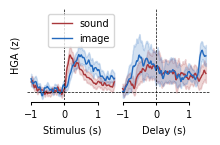

In [8]:
rois = ['AIC']
tasks = ['PictureNaming']
modalities = ['sound', 'image']

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    & (HGAs.modality.isin(modalities))
]

phases = ['stimulus', 'delay', 'go', 'response']
phases = ['stimulus','delay']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 3*cm))
plt.subplots_adjust(wspace=0)

for phase, ax in zip(phases, axes):
    legend_ = ax == axes[-2]
    sns.lineplot(
        data=subset[subset.phase == phase],
        x='time', y='value',
        hue='modality', hue_order=modalities,
        ax=ax, palette=[red, blue], legend=legend_, lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    leg = ax.get_legend()
    if leg is not None:
        if ax == axes[-2]:
            ax.legend(title='', fontsize=7)
        else:
            leg.remove()
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1)

axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

plt.savefig('grantfig/aim1_1a_input_modality_AIC.svg', dpi=300, bbox_inches='tight')
plt.show()

### Spatial: Input Modality (stimulus)

category
Sound-only    21
Image-only    13
Overlap       21
Name: channel, dtype: int64


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-05-19 10:04:32.092 (2480.856s) [    7F6111E82740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x508d63d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

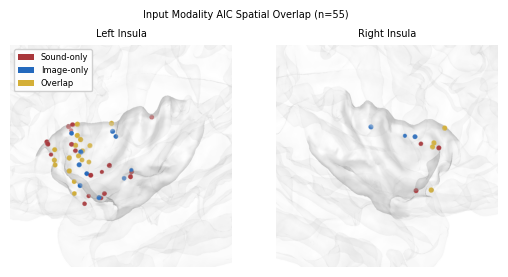

In [13]:
panel_a_subset = HGAs[
    (HGAs.task == 'PictureNaming')
    & (HGAs.roi == 'AIC')
    & (HGAs.modality.isin(['sound', 'image']))
].copy()

panel_a_windows = [
    ('stimulus', None, None),
    ('delay', None, 1.0),
]

sound_channels = get_sig_channels(panel_a_subset, panel_a_windows, 'modality', 'sound')
image_channels = get_sig_channels(panel_a_subset, panel_a_windows, 'modality', 'image')
panel_a_categories = classify_channel_overlap(sound_channels, image_channels, 'Sound', 'Image')

panel_a_spatial = build_spatial_overlap(panel_a_subset, panel_a_windows, panel_a_categories)
panel_a_order = ['Sound-only', 'Image-only', 'Overlap']
panel_a_colors = {
    'Sound-only': red,
    'Image-only': blue,
    'Overlap': insula_color,
}

plot_aic_spatial_categories(
    panel_a_spatial,
    color_map=panel_a_colors,
    category_order=panel_a_order,
    title='Input Modality AIC Spatial Overlap',
    save_path='grantfig/aim1_1a_input_modality_spatial_AIC.svg',
)

## Panel B: Lexical Delay vs No-Delay (Decision)

Panel B common subjects (n=4): ['D0028', 'D0071', 'D0092', 'D0094']


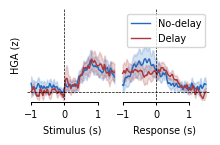

In [23]:
rois = ['AIC']
panel_b_tasks = ['LexicalNoDelay', 'LexicalDelay']
panel_b_description = 'Decision'

panel_b_common_subjects = common_subjects_across_tasks(
    HGAs,
    panel_b_tasks,
    roi='AIC',
    description=panel_b_description,
    modality='sound',
)
print(f'Panel B common subjects (n={len(panel_b_common_subjects)}):', sorted(panel_b_common_subjects))

subset = HGAs[
    HGAs.task.isin(panel_b_tasks)
    & HGAs.roi.isin(rois)
    & (HGAs.description == panel_b_description)
    & (HGAs.modality == 'sound')
    & HGAs.subject.isin(panel_b_common_subjects)
].copy()

subset['task_label'] = subset['task'].map({
    'LexicalNoDelay': 'No-delay',
    'LexicalDelay': 'Delay',
})
task_order = ['No-delay', 'Delay']

phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 3*cm))
plt.subplots_adjust(wspace=0)

for phase, ax in zip(phases, axes):
    legend_ = ax == axes[-1]
    sns.lineplot(
        data=subset[subset.phase == phase],
        x='time', y='value',
        hue='task_label', hue_order=task_order,
        ax=ax, palette=[blue, red], legend=legend_, lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    leg = ax.get_legend()
    if leg is not None:
        if ax == axes[-1]:
            ax.legend(title='', fontsize=7)
        else:
            leg.remove()
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1)

axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

plt.savefig('grantfig/aim1_1b_delay_nodelay_decision_AIC.svg', dpi=300, bbox_inches='tight')
plt.show()

### Spatial: Output Effector (response)

category
No-delay-only    3
Delay-only       4
Overlap          7
Name: channel, dtype: int64


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-05-19 10:17:43.838 (3272.602s) [    7F6111E82740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x53ab2770): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

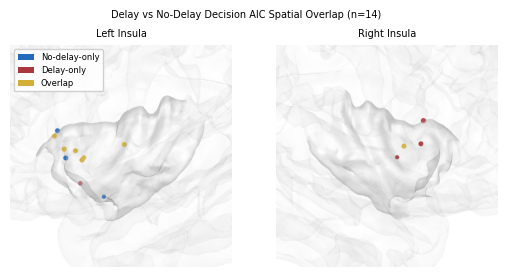

In [24]:
panel_b_tasks = ['LexicalNoDelay', 'LexicalDelay']
panel_b_common_subjects = common_subjects_across_tasks(
    HGAs,
    panel_b_tasks,
    roi='AIC',
    description='Decision',
    modality='sound',
)

panel_b_subset = HGAs[
    HGAs.task.isin(panel_b_tasks)
    & (HGAs.roi == 'AIC')
    & (HGAs.modality == 'sound')
    & (HGAs.description == 'Decision')
    & HGAs.subject.isin(panel_b_common_subjects)
].copy()

panel_b_windows = [
    ('response', -0.5, 0.5),
]

nodelay_channels = get_sig_channels(panel_b_subset, panel_b_windows, 'task', 'LexicalNoDelay')
delay_channels = get_sig_channels(panel_b_subset, panel_b_windows, 'task', 'LexicalDelay')
panel_b_categories = classify_channel_overlap(nodelay_channels, delay_channels, 'No-delay', 'Delay')

panel_b_spatial = build_spatial_overlap(panel_b_subset, panel_b_windows, panel_b_categories)
panel_b_order = ['No-delay-only', 'Delay-only', 'Overlap']
panel_b_colors = {
    'No-delay-only': blue,
    'Delay-only': red,
    'Overlap': insula_color,
}

plot_aic_spatial_categories(
    panel_b_spatial,
    color_map=panel_b_colors,
    category_order=panel_b_order,
    title='Delay vs No-Delay Decision AIC Spatial Overlap',
    save_path='grantfig/aim1_1b_delay_nodelay_decision_spatial_AIC.svg',
)

## Panel C: Content / Spatial Overlap

In [8]:
STERNBERG_ROOT = '../../sternberg/results/EnvironmentalSternberg(bipolar)'

sternberg_paths = BIDSPath(
    root=STERNBERG_ROOT,
    datatype='HGA',
    suffix='condition',
    check=False,
).match()
print(f'EnvironmentalSternberg condition files: {len(sternberg_paths)}')

HGAs_sternberg = pd.concat([pd.read_csv(p) for p in tqdm(sternberg_paths)], ignore_index=True)
HGAs_sternberg['phase'] = HGAs_sternberg['phase'].str.lower()

HGAs_sternberg.loc[HGAs_sternberg.roi == 'INS', 'roi'] = 'Insula'
HGAs_sternberg.loc[HGAs_sternberg.roi == 'PrG', 'roi'] = 'SMC'
HGAs_sternberg.loc[HGAs_sternberg.roi == 'PoG', 'roi'] = 'SMC'
HGAs_sternberg.loc[HGAs_sternberg.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs_sternberg.loc[HGAs_sternberg.roi == 'HG', 'roi'] = 'STG'
HGAs_sternberg.loc[HGAs_sternberg.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal',
]), 'roi'] = 'PCC'
eedacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant',
]
HGAs_sternberg.loc[HGAs_sternberg.label.isin(dacc_labels), 'roi'] = 'dACC'
HGAs_sternberg.loc[HGAs_sternberg.roi == 'CG', 'roi'] = 'ACC'

HGAs_sternberg['roi'] = HGAs_sternberg.apply(classify_insula_row, axis=1, y_threshold=0)
HGAs_sternberg = HGAs_sternberg[~HGAs_sternberg.channel.isin(exclude_chn)]
HGAs_sternberg[['x', 'y', 'z']] = HGAs_sternberg[['x', 'y', 'z']].values + translation
HGAs_sternberg = add_sternberg_content_group(HGAs_sternberg)

print(
    f"Sternberg: subjects={HGAs_sternberg.subject.nunique()}, "
    f"AIC rows={len(HGAs_sternberg[HGAs_sternberg.roi == 'AIC'])}, "
    f"loads={sorted(HGAs_sternberg.description.unique())}"
)


EnvironmentalSternberg condition files: 492


100%|██████████| 492/492 [00:14<00:00, 35.01it/s]


Sternberg: subjects=31, AIC rows=599040, loads=['load3', 'load5', 'load7', 'load9']


### Panel C1 temporal: Environmental Sound vs Word vs Non-word (grand average)

Panel C1: subjects=18, channels=77


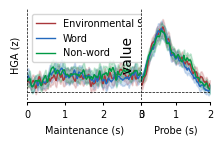

In [12]:
cfg = PANEL_C_CONFIG
panel_c1_subset = HGAs_sternberg[
    (HGAs_sternberg.roi == 'AIC')
    & (HGAs_sternberg.modality == 'sound')
].copy()

print(
    f"Panel C1: subjects={panel_c1_subset.subject.nunique()}, "
    f"channels={panel_c1_subset.channel.nunique()}"
)

panel_c1_temporal = panel_c1_subset.copy()
panel_c1_temporal['condition_label'] = panel_c1_temporal['condition_group'].map({
    'environment': 'Environmental Sound',
    'word': 'Word',
    'nonword': 'Non-word',
})

phases = cfg['panel_c1_phases']
phase_width_ratios = cfg['panel_c1_phase_width_ratios']
fig_width_cm = cfg['panel_c1_fig_width_cm']
condition_order = ['Environmental Sound', 'Word', 'Non-word']
fig, axes = plt.subplots(
    nrows=1, ncols=len(phases),
    figsize=(fig_width_cm * cm, 3 * cm),
    gridspec_kw={'width_ratios': phase_width_ratios},
)
plt.subplots_adjust(wspace=0)

for phase, ax in zip(phases, axes):
    xlim, _ = get_panel_c1_phase_xaxis(phase)
    phase_df = panel_c1_temporal[
        (panel_c1_temporal.phase == phase)
        & (panel_c1_temporal.time >= xlim[0])
        & (panel_c1_temporal.time <= xlim[1])
    ]
    legend_ = ax == axes[-2]
    sns.lineplot(
        data=phase_df,
        x='time', y='value',
        hue='condition_label', hue_order=condition_order,
        ax=ax, palette=[red, blue, green], legend=legend_, lw=1,
    )
    apply_panel_c1_phase_xaxis(ax, phase)
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    leg = ax.get_legend()
    if leg is not None:
        if ax == axes[-2]:
            ax.legend(title='', fontsize=7)
        else:
            leg.remove()
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1)

axes[0].set_ylabel('HGA (z)', fontsize=7)
plt.savefig('grantfig/aim1_1c_environment_vs_speech_AIC_waveform.svg', dpi=300, bbox_inches='tight')
plt.show()


### Panel C1 temporal: Environmental Sound vs Word vs Non-word (channel heatmap)

Panel C1: subjects=18, channels=77


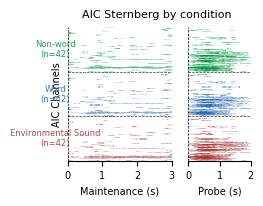

In [13]:
cfg = PANEL_C_CONFIG
panel_c1_subset = HGAs_sternberg[
    (HGAs_sternberg.roi == 'AIC')
    & (HGAs_sternberg.modality == 'sound')
].copy()

print(
    f"Panel C1: subjects={panel_c1_subset.subject.nunique()}, "
    f"channels={panel_c1_subset.channel.nunique()}"
)

plot_sternberg_condition_channel_heatmap(
    panel_c1_subset,
    roi='AIC',
    savepath='grantfig/aim1_1c_environment_vs_speech_AIC.svg',
)
plt.show()

### Panel C1 spatial: Environment vs Speech

category
Environment-only     0
Speech-only          0
Overlap             42
Name: channel, dtype: int64


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 12:19:44.221 (3520.819s) [    7FA677CD2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x8e9da90): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

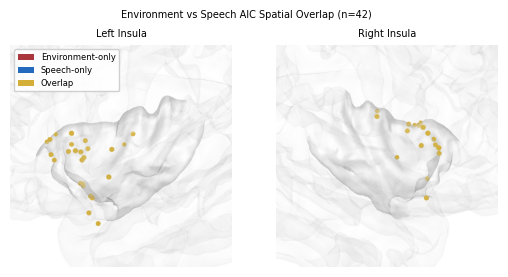

In [40]:
cfg = PANEL_C_CONFIG
panel_c1_windows = cfg['panel_c1_windows']
panel_c1_subset = HGAs_sternberg[
    (HGAs_sternberg.roi == 'AIC') & (HGAs_sternberg.modality == 'sound')
].copy()

env_channels = get_sig_channels_any_load(
    panel_c1_subset, panel_c1_windows, 'content_group', 'environment',
)
speech_channels = get_sig_channels_any_load(
    panel_c1_subset, panel_c1_windows, 'content_group', 'Speech',
)
panel_c1_categories = classify_channel_overlap(
    env_channels, speech_channels, 'Environment', 'Speech',
)
panel_c1_spatial = build_spatial_overlap(
    panel_c1_subset, panel_c1_windows, panel_c1_categories,
)
panel_c1_order = ['Environment-only', 'Speech-only', 'Overlap']
panel_c1_colors = {
    'Environment-only': red,
    'Speech-only': blue,
    'Overlap': insula_color,
}

plot_aic_spatial_categories(
    panel_c1_spatial,
    color_map=panel_c1_colors,
    category_order=panel_c1_order,
    title='Environment vs Speech AIC Spatial Overlap',
    save_path='grantfig/aim1_1c_environment_vs_speech_spatial_AIC.svg',
)


### Panel C2 temporal: Sternberg maintenance vs Lexical Repeat delay

Panel C2 common subjects (n=9): ['D0047', 'D0053', 'D0055', 'D0071', 'D0080', 'D0094', 'D0096', 'D0101', 'D0103']


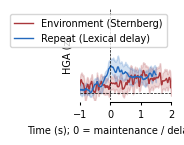

In [43]:
cfg = PANEL_C_CONFIG
st_phase = cfg['sternberg_phase']
rep_phase = cfg['repeat_phase']

panel_c2_sternberg_all = HGAs_sternberg[
    (HGAs_sternberg.roi == 'AIC') & (HGAs_sternberg.modality == 'sound')
].copy()
panel_c2_repeat_all = HGAs[
    (HGAs.task == cfg['repeat_task'])
    & (HGAs.description == cfg['repeat_description'])
    & (HGAs.roi == 'AIC')
    & (HGAs.modality == 'sound')
].copy()

panel_c2_sternberg, panel_c2_repeat, _ = subset_panel_c2_common(
    panel_c2_sternberg_all, panel_c2_repeat_all,
)

# Sternberg environment (maintenance) vs lexical repeat (delay), same axes
st_env = panel_c2_sternberg[
    (panel_c2_sternberg.phase == st_phase)
    & (panel_c2_sternberg.content_group == 'environment')
    & (panel_c2_sternberg.time <= 2)
]
rep_delay = panel_c2_repeat[
    (panel_c2_repeat.phase == rep_phase)
    & (panel_c2_repeat.time <= 2)
]

fig, ax = plt.subplots(figsize=(3 * cm, 3 * cm))
sns.lineplot(
    data=st_env, x='time', y='value',
    ax=ax, color=red, label='Environment (Sternberg)', lw=1,
)
sns.lineplot(
    data=rep_delay, x='time', y='value',
    ax=ax, color=blue, label='Repeat (Lexical delay)', lw=1,
)
ax.set_xlabel(f'Time (s); 0 = {st_phase} / {rep_phase} onset', fontsize=7)
ax.set_ylabel('HGA (z)', fontsize=7)
ax.legend(title='', fontsize=7)

ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.tick_params(labelsize=7, width=0.75, length=2, which='both')
plt.setp(ax.spines.values(), linewidth=0.75)
sns.despine(ax=ax, offset=1, trim=True)
ax.set_yticklabels([])
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.set_xlim(-1, 2)
ax.set_xticks([-1, 0, 1, 2])
ax.set_ylim(-0.1, 1.2)

plt.savefig('grantfig/aim1_1c_sternberg_vs_repeat_AIC.svg', dpi=300, bbox_inches='tight')
plt.show()

### Panel C2 spatial: Environment (Sternberg) vs Repeat overlap

Panel C2 common subjects (n=9): ['D0047', 'D0053', 'D0055', 'D0071', 'D0080', 'D0094', 'D0096', 'D0101', 'D0103']
category
Environment-only    11
Repeat-only          5
Overlap              8
Name: channel, dtype: int64


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 12:22:22.631 (3679.230s) [    7FA677CD2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x7cf5590): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

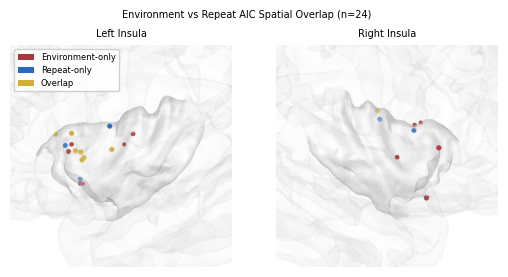

In [44]:
cfg = PANEL_C_CONFIG
st_windows = cfg['sternberg_windows']
rep_windows = cfg['repeat_windows']

panel_c2_sternberg_all = HGAs_sternberg[
    (HGAs_sternberg.roi == 'AIC') & (HGAs_sternberg.modality == 'sound')
].copy()
panel_c2_repeat_all = HGAs[
    (HGAs.task == cfg['repeat_task'])
    & (HGAs.description == cfg['repeat_description'])
    & (HGAs.roi == 'AIC')
    & (HGAs.modality == 'sound')
].copy()

panel_c2_sternberg, panel_c2_repeat, _ = subset_panel_c2_common(
    panel_c2_sternberg_all, panel_c2_repeat_all,
)

sternberg_channels = get_sternberg_sig_channels(panel_c2_sternberg, st_windows, cfg)
repeat_channels = get_sig_channels(
    panel_c2_repeat, rep_windows, 'description', cfg['repeat_description'],
)
panel_c2_categories = classify_channel_overlap(
    sternberg_channels, repeat_channels, 'Environment', 'Repeat',
)
panel_c2_spatial = build_spatial_overlap_cross(
    panel_c2_sternberg, panel_c2_repeat,
    st_windows, rep_windows, panel_c2_categories,
)
panel_c2_order = ['Environment-only', 'Repeat-only', 'Overlap']
panel_c2_colors = {
    'Environment-only': red,
    'Repeat-only': blue,
    'Overlap': insula_color,
}

plot_aic_spatial_categories(
    panel_c2_spatial,
    color_map=panel_c2_colors,
    category_order=panel_c2_order,
    title='Environment vs Repeat AIC Spatial Overlap',
    save_path='grantfig/aim1_1c_environment_vs_repeat_spatial_AIC.svg',
)


# Aim 1.2
## Dissociating Maintenance from Sensory/Execution

**Panel A** — AIC vs SMC (Lexical Repeat, sound): lineplot + channel heatmaps.

**Panel B** — *Deferred.* Planned comparisons:
1. **Passive vs Delayed Repeat** (maintenance vs passive sensory)
2. **Delayed Repeat vs No-delay Repeat** (maintenance vs execution; stimulus + response windows)

Cells below with three traces on one plot are **placeholder only** — skip until Panel B is implemented.

### Panel A: AIC vs SMC (Repeat)

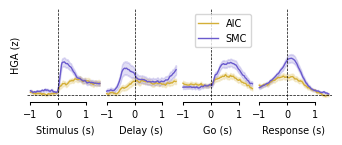

In [9]:
rois = ['AIC', 'SMC']
roi_colors = [insula_color, smc_color]

panel_a_subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == 'sound')
    & (HGAs.roi.isin(rois))
    & (HGAs.subject != 'D0121')
].copy()

phases = ['stimulus', 'delay', 'go', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5 * len(phases) * cm, 3 * cm))
plt.subplots_adjust(wspace=0)

for ax, phase in zip(axes, phases):
    legend = ax == axes[-2]
    sns.lineplot(
        data=panel_a_subset[panel_a_subset.phase == phase],
        x='time', y='value',
        hue='roi', hue_order=rois,
        ax=ax, palette=roi_colors, legend=legend, lw=1,
    )
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    leg = ax.get_legend()
    if leg is not None:
        if ax == axes[-2]:
            ax.legend(title='', fontsize=7)
        else:
            leg.remove()
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1.5)
    if ax != axes[0]:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('HGA (z)', fontsize=7)

plt.savefig('grantfig/aim1_2a_aic_vs_smc_repeat.svg', dpi=300, bbox_inches='tight')
plt.show()

#### Panel A: channel heatmaps (Repeat)

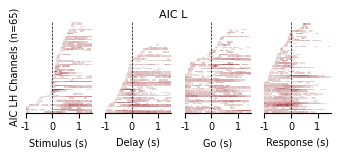

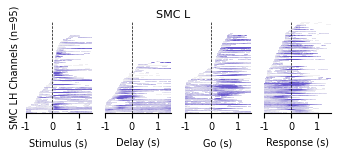

In [56]:
smc_cmap = sns.light_palette(smc_color, as_cmap=True)

for roi, cmap in [('AIC', reds), ('SMC', smc_cmap)]:
    plot_repeat_channel_heatmap(
        HGAs,
        roi=roi,
        hemi='L',
        cmap=cmap,
        savepath=f'grantfig/aim1_2a_heatmap_{roi}_L.svg',
    )
    plt.show()

### Panel B1: Passive vs Repeat (stimulus + response)

SMC Passive in the **Response** panel is shifted **−0.7 s** post-hoc (auditory bump moved off pre-response window). All panels share **xlim −0.5 to 1.5 s**.

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3933454/3794391639.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3933454/3794391639.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3933454/3794391639.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3933454/3794391639.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


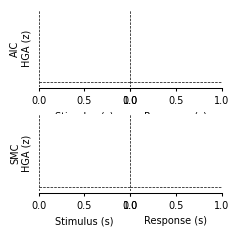

In [15]:
AIM_12B1_COND_MAP = {
    ('LexicalNoDelay', 'Passive'): 'Passive',
    # ('PictureNaming', 'Passive'): 'Passive',
    ('LexicalNoDelay', 'Repeat'): 'Repeat',
    ('LexicalDelay', 'Repeat'): 'Repeat',
    # ('PictureNaming', 'Repeat'): 'Repeat',
}
AIM_12B1_COND_ORDER = ['Passive', 'Repeat']
AIM_12B1_COND_COLORS = ['gray', red]
AIM_12B1_XLIM = (-0.5, 1.5)
PASSIVE_SMC_RESPONSE_SHIFT = -0.7

def plot_df_for_panel(df, roi, phase):
    sub = df[(df.roi == roi) & (df.phase == phase)].copy()
    if roi == 'SMC' and phase == 'response':
        passive = sub['condition'] == 'Passive'
        sub.loc[passive, 'time'] = sub.loc[passive, 'time'] + PASSIVE_SMC_RESPONSE_SHIFT
    return sub

rois = ['AIC', 'SMC']
phases = ['stimulus', 'response']

subset_12b1 = HGAs[
    (HGAs.modality == 'sound')
    & (HGAs.roi.isin(rois))
    & (HGAs.subject != 'D0121')
].copy()
subset_12b1['condition'] = subset_12b1.apply(
    lambda r: AIM_12B1_COND_MAP.get((r['task'], r['description'])), axis=1,
)
subset_12b1 = subset_12b1[subset_12b1.condition.notna()]

fig, axes = plt.subplots(
    nrows=len(rois), ncols=len(phases),
    figsize=(3 * len(phases) * cm, 3 * len(rois) * cm),
    sharey='row',
)
plt.subplots_adjust(wspace=0, hspace=0.35)

for i, roi in enumerate(rois):
    roi_data = subset_12b1[subset_12b1.roi == roi]
    for j, phase in enumerate(phases):
        ax = axes[i, j]
        legend_ = (i == 0) and (j == len(phases) - 2)
        plot_data = plot_df_for_panel(roi_data, roi, phase)
        sns.lineplot(
            data=plot_data,
            x='time', y='value',
            hue='condition', hue_order=AIM_12B1_COND_ORDER,
            ax=ax, palette=AIM_12B1_COND_COLORS, legend=legend_, lw=1,
        )
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        if j == 0:
            ax.set_ylabel(f'{roi}\nHGA (z)', fontsize=7)
        else:
            ax.set_ylabel('', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    leg = ax.get_legend()
    if leg is not None:
        if ax is axes[0, len(phases) - 2]:
            ax.legend(title='', fontsize=7)
        else:
            leg.remove()
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1.5)
    ax.set_xlim(*AIM_12B1_XLIM)

plt.savefig('grantfig/aim1_2b_passive_vs_repeat_AIC_SMC.svg', dpi=300, bbox_inches='tight')
plt.show()

### Panel B2: Delayed Repeat vs No-delay Repeat — *deferred*


# Aim 1.3
## Cognitive Demand Modulation

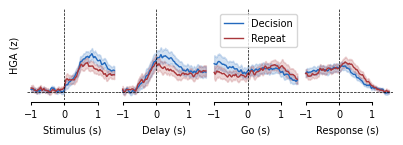

In [14]:
rois = ['AIC']
tasks = ['LexicalDelay']
descriptions = ['Decision', 'Repeat']

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    & (HGAs.description.isin(descriptions))
    & (HGAs.modality == 'sound')
]

phases = ['stimulus', 'delay', 'go', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 3*cm))
plt.subplots_adjust(wspace=0)

for phase, ax in zip(phases, axes):
    legend_ = ax == axes[-2]
    sns.lineplot(
        data=subset[subset.phase == phase],
        x='time', y='value',
        hue='description', hue_order=descriptions,
        ax=ax, palette=[blue, red], legend=legend_, lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    leg = ax.get_legend()
    if leg is not None:
        if ax == axes[-2]:
            ax.legend(title='', fontsize=7)
        else:
            leg.remove()
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1)

axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

plt.savefig('grantfig/aim1_3_cognitive_demand_AIC.svg', dpi=300, bbox_inches='tight')
plt.show()

### Spatial: Decision > Repeat (AIC)

Found 44 DecisionVsRepeat contrast files


100%|██████████| 44/44 [00:02<00:00, 15.81it/s]


DecisionVsRepeat rows=1726720, subjects=44, channels=1349
Decision > Repeat spatial channels: n=22, subjects=10, roi=AIC, phase=delay, window=(0, 0.8)
Decision > Repeat: plotting 22 AIC channels


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-05-19 13:28:05.979 (14694.743s) [    7F6111E82740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x42fba9f0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/ca

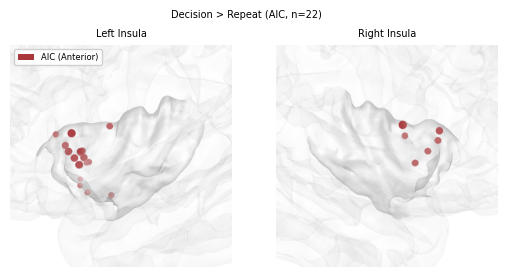

In [65]:
PANEL_13_CONFIG = {
    'tasks': ('LexicalDelay',),
    'phase': 'delay',
    't_window': (0, 0.8),
    'roi': 'AIC',
}

dec_vs_rep_13 = load_decision_vs_repeat_contrast(tasks=PANEL_13_CONFIG['tasks'])
aim13_decision_spatial = get_decision_gt_repeat_channels(
    dec_vs_rep_13,
    phase=PANEL_13_CONFIG['phase'],
    t_window=PANEL_13_CONFIG['t_window'],
    roi=PANEL_13_CONFIG['roi'],
)

plot_insula_decision_effect_spatial(
    aim13_decision_spatial,
    roi=PANEL_13_CONFIG['roi'],
    title='Decision > Repeat',
    save_path='grantfig/aim1_3_cognitive_demand_spatial_AIC.svg',
)

## Reaction time: temporal dynamics (Decision, shared Stimulus / Response)

AIC mean R² vs time for **LexicalDelay** (speech production, red) and **LexicalNoDelay** (button press, blue) on the same Stimulus and Response panels; bars = cluster-corrected significance (≥10% of AIC channels at that time).


In [ ]:
rt_coords = HGAs[['channel', 'roi']].drop_duplicates('channel')

rt_delay = prepare_rt_with_roi(
    load_rt_results('LexicalDelay', ref=RT_PANEL_CONFIG['ref']),
    rt_coords, RT_PANEL_CONFIG['description'],
)
rt_nodelay = prepare_rt_with_roi(
    load_rt_results('LexicalNoDelay', ref=RT_PANEL_CONFIG['ref']),
    rt_coords, RT_PANEL_CONFIG['description'],
)

plot_rt_temporal_task_comparison(
    [
        ('Delay', rt_delay),
        ('No-delay', rt_nodelay),
    ],
    title='RT prediction: Decision (LexicalDelay vs LexicalNoDelay)',
    save_path='grantfig/aim1_rt_delay_vs_nodelay_decision_temporal_AIC.svg',
)

plot_rt_task_heatmap_comparison(
    [
        ('Delay', rt_delay),
        ('No-delay', rt_nodelay),
    ],
    title='RT prediction: Decision (LexicalDelay vs LexicalNoDelay)',
    save_path='grantfig/aim1_rt_delay_vs_nodelay_decision_heatmap_AIC.svg',
)


## Reaction time: RT-predicting electrodes (spatial overlap)

LexicalDelay — Decision, **Delay phase** (any significant cluster). LexicalNoDelay — Decision, **Stimulus ∪ Response** (any significant cluster in either phase).


RT LexicalDelay: 100%|██████████| 320/320 [00:04<00:00, 68.09it/s]


RT LexicalDelay: rows=927,072, subjects=40, phases=['Delay', 'Go', 'Response', 'Stimulus']


RT LexicalNoDelay: 100%|██████████| 48/48 [00:00<00:00, 61.29it/s]


RT LexicalNoDelay: rows=131,776, subjects=12, phases=['Response', 'Stimulus']
NoDelay RT sig channels: Stimulus=75, Response=59, union=115
LexicalDelay Delay sig channels: 109
LexicalNoDelay Stimulus|Response sig channels: 115
category
Delay-only       8
No-delay-only    2
Overlap          0
Name: channel, dtype: int64


2026-05-23 22:27:50.713 (24453.729s) [    7F9C99798740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-05-23 22:27:50.782 (24453.798s) [    7F9C99798740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x45da3d30): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: e

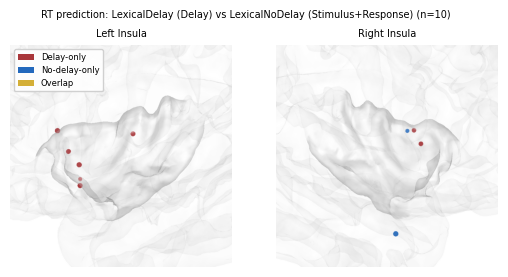

In [28]:
cfg = RT_PANEL_CONFIG
rt_delay = load_rt_results(cfg['delay_task'], ref=cfg['ref'])
rt_nodelay = load_rt_results(cfg['nodelay_task'], ref=cfg['ref'])

ch_delay, scores_delay = get_sig_rt_channel_scores(
    rt_delay, cfg['delay_phase'], cfg['description'],
)
ch_nodelay, scores_nodelay, _, _ = get_nodelay_sig_rt_channels(rt_nodelay, cfg)

print(f'LexicalDelay Delay sig channels: {len(ch_delay)}')
print(f'LexicalNoDelay Stimulus|Response sig channels: {len(ch_nodelay)}')

rt_coords = (
    HGAs[['channel', 'roi', 'label', 'hemi', 'x', 'y', 'z', 'subject']]
    .drop_duplicates('channel')
)

rt_categories = classify_channel_overlap(ch_delay, ch_nodelay, 'Delay', 'No-delay')
rt_spatial = build_rt_spatial_overlap(
    scores_delay, scores_nodelay, rt_categories, rt_coords,
)

rt_order = ['Delay-only', 'No-delay-only', 'Overlap']
rt_colors = {
    'Delay-only': red,
    'No-delay-only': blue,
    'Overlap': insula_color,
}

plot_aic_spatial_categories(
    rt_spatial,
    color_map=rt_colors,
    category_order=rt_order,
    title='RT prediction: LexicalDelay (Delay) vs LexicalNoDelay (Stimulus+Response)',
    save_path='grantfig/aim1_rt_delay_vs_nodelay_decision_spatial_AIC.svg',
)
